In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn psutil folium

import pandas as pd
import numpy as np
import time
import psutil
import threading
import os
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carregamento dos dados

In [2]:
files = [
    "../data/processed/test_eco_10_min_07_01.csv",
    "../data/processed/test_nor_10_min_07_01.csv",
    "../data/processed/test_tur_10_min_07_01.csv"
]

df_list = []
for file_path in files:
    try:
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df)
        print(f"Carregado: {file_path}")
    except FileNotFoundError:
        print(f"ERRO: Arquivo {file_path} não encontrado.")

if not df_list:
    raise ValueError("Nenhum arquivo foi carregado. Verifique os caminhos.")

df = pd.concat(df_list, ignore_index=True)

Carregado: ../data/processed/test_eco_10_min_07_01.csv
Carregado: ../data/processed/test_nor_10_min_07_01.csv
Carregado: ../data/processed/test_tur_10_min_07_01.csv


## Processamento dos dados

In [3]:
# Mapear os modos para valores numéricos
def map_mode(val):
    val = str(val).lower()
    if 'eco' in val: return 0
    if 'nor' in val: return 1
    if 'tur' in val: return 2
    return -1 # Caso de erro

df['mode'] = df['testCase'].apply(map_mode)

# Calcular o tempo decorrido em segundos desde o início de teste em cada modo
df = df.sort_values(by=['testCase', 'receivedAtMs'])
df['elapsed_time_s'] = df.groupby('testCase')['receivedAtMs'].transform(lambda x: (x - x.min()) / 1000.0)

#Deixando só as colunas relevantes
cols_to_drop = ['id', 'deviceId', 'sampleId', 'batteryC', 'testCase', 
                'receivedAt', 'receivedAtMs', 'headingDeg', 'accuracyM']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

df = df.rename(columns={
    'referenceC': 'temp_amb',
    'speedMps': 'speed',
    'lng': 'lon',
    'accel_x': 'accX', 
    'accel_y': 'accY', 
    'accel_z': 'accZ',
    'motorC': 'temp_motor'
})

print(f"Dataset processado: {df.shape[0]} registros.")
df.head()

Dataset processado: 1280 registros.


,lat,lon,speed,temp_motor,temp_amb,accX,accY,accZ,mode,elapsed_time_s
0,-8.055608,-34.951114,0.117372,23.50,27.81,1055,398,220,0,0.000
1,-8.055608,-34.951111,0.061618,23.56,27.81,1053,403,218,0,1.983
2,-8.055613,-34.951110,0.060315,23.56,27.88,1056,401,218,0,3.002
3,-8.055611,-34.951111,0.391130,23.62,27.88,1055,398,217,0,5.073
4,-8.055609,-34.951111,0.324248,23.62,27.88,1057,401,214,0,6.103


## Análise descritiva


[Estatísticas Descritivas]
             count         mean         std     min         25%          50%  \
temp_motor  1280.0    31.009234    9.283835 -127.00   29.880000    32.560000   
speed       1280.0     0.178040    0.112846   -1.00    0.094734     0.174308   
accX        1280.0  1076.198437  179.394280    0.00  981.000000  1075.000000   
temp_amb    1280.0    28.920797    0.387196   27.81   28.750000    28.940000   

                    75%          max  
temp_motor    33.190000    35.440000  
speed          0.249044     2.514518  
accX        1166.000000  2338.000000  
temp_amb      29.190000    29.500000  

[Checagem de Zeros (Possíveis falhas de sensor)]
Registros com Velocidade = 0: 2 (0.2%)
Registros com GPS zerado (Lat/Lon=0): 0 (0.0%)
-> Gráfico salvo: eda_evolucao_temp.png


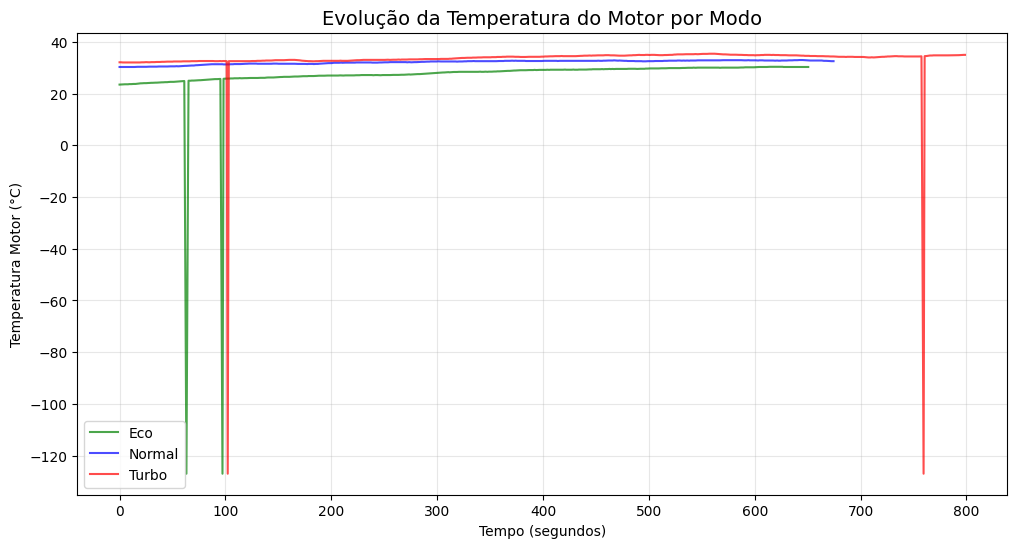

/tmp/ipykernel_137539/19708181.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mode', y='temp_motor', data=df, palette='viridis')


-> Gráfico salvo: eda_boxplot_temp.png


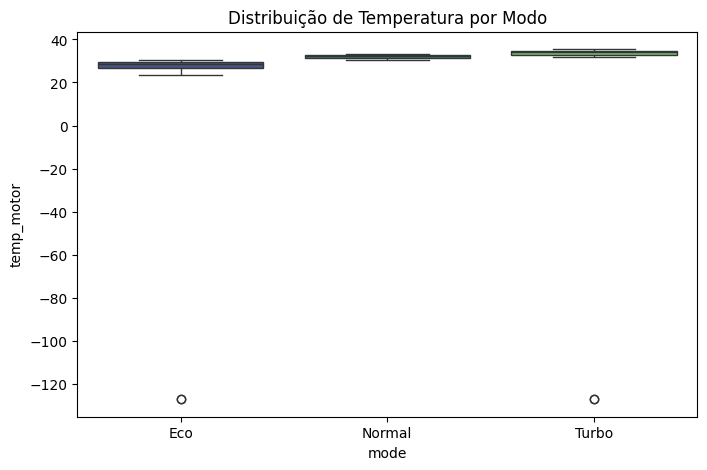

-> Gráfico salvo: eda_correlacao.png


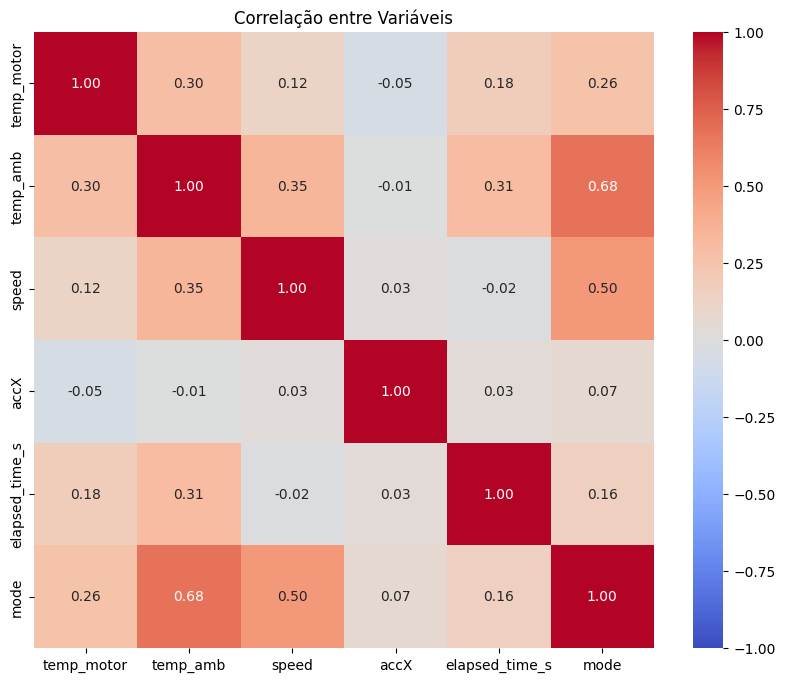

-> Gráfico salvo: eda_distribuicao.png


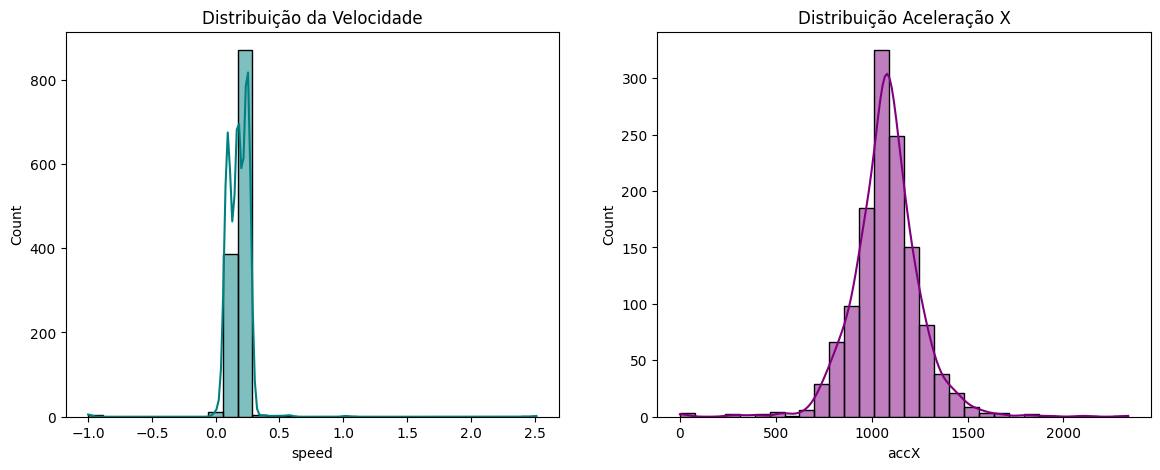

In [ ]:
print("\n[Estatísticas Descritivas]")
print(df[['temp_motor', 'speed', 'accX', 'temp_amb']].describe().T)

print("\n[Checagem de Zeros (Possíveis falhas de sensor)]")
zeros_speed = (df['speed'] == 0).sum()
zeros_gps = ((df['lat'] == 0) & (df['lon'] == 0)).sum()
print(f"Registros com Velocidade = 0: {zeros_speed} ({zeros_speed/len(df):.1%})")
print(f"Registros com GPS zerado (Lat/Lon=0): {zeros_gps} ({zeros_gps/len(df):.1%})")

# 3.2 Gráfico: Evolução da Temperatura por Modo
plt.figure(figsize=(12, 6))
modes = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for m_code, m_name in modes.items():
    subset = df[df['mode'] == m_code]
    plt.plot(subset['elapsed_time_s'], subset['temp_motor'], label=m_name, color=colors[m_code], alpha=0.7)

plt.title('Evolução da Temperatura do Motor por Modo', fontsize=14)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Temperatura Motor (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('eda_evolucao_temp.png')
print("-> Gráfico salvo: eda_evolucao_temp.png")
plt.show()
plt.close()

# 3.3 Gráfico: Boxplot Comparativo
plt.figure(figsize=(8, 5))
sns.boxplot(x='mode', y='temp_motor', data=df, palette='viridis')
plt.xticks([0, 1, 2], ['Eco', 'Normal', 'Turbo'])
plt.title('Distribuição de Temperatura por Modo')
plt.savefig('eda_boxplot_temp.png')
print("-> Gráfico salvo: eda_boxplot_temp.png")
plt.show()
plt.close()

# 3.4 Gráfico: Matriz de Correlação
plt.figure(figsize=(10, 8))
cols_corr = ['temp_motor', 'temp_amb', 'speed', 'accX', 'elapsed_time_s', 'mode']
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre Variáveis')
plt.savefig('eda_correlacao.png')
print("-> Gráfico salvo: eda_correlacao.png")
plt.show()
plt.close()

# 3.5 Histograma de Velocidade e Aceleração
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribuição da Velocidade')
sns.histplot(df['accX'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribuição Aceleração X')
plt.savefig('eda_distribuicao.png')
print("-> Gráfico salvo: eda_distribuicao.png")
plt.show()
plt.close()

## Mapa de trajeto

In [17]:
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

mode_labels = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for mode_id, mode_name in mode_labels.items():

    df_mode = df[df['mode'] == mode_id].copy()
    

    df_mode = df_mode.sort_values(by='elapsed_time_s')
    

    df_mode = df_mode[
        (df_mode['lat'].notna()) & 
        (df_mode['lon'].notna()) & 
        (df_mode['lat'] != 0) & 
        (df_mode['lon'] != 0)
    ]
    
    if df_mode.empty:
        print(f"Sem dados válidos de GPS para o modo {mode_name}")
        continue
        
    print(f"Processando modo {mode_name}: {len(df_mode)} pontos de GPS encontrados.")


    center_lat = df_mode['lat'].mean()
    center_lon = df_mode['lon'].mean()
    
    # Criar mapa base
    m = folium.Map(location=[center_lat, center_lon], zoom_start=15, control_scale=True)
    
    # Criar lista de tuplas (Lat, Lon) garantindo float
    points = list(zip(df_mode['lat'].astype(float), df_mode['lon'].astype(float)))
    
    if len(points) > 1:
        # Adicionar Trajeto (Polilinha)
        folium.PolyLine(
            points, 
            color=colors[mode_id], 
            weight=4, 
            opacity=0.8, 
            tooltip=f"Trajeto {mode_name}"
        ).add_to(m)
        
        # Marcador de INÍCIO (Verde)
        folium.Marker(
            points[0], 
            popup=f"Início {mode_name}", 
            icon=folium.Icon(color='green', icon='play', prefix='fa')
        ).add_to(m)
        
        # Marcador de FIM (Vermelho)
        folium.Marker(
            points[-1], 
            popup=f"Fim {mode_name}", 
            icon=folium.Icon(color='red', icon='stop', prefix='fa')
        ).add_to(m)
    else:
        print(f"Aviso: Menos de 2 pontos para traçar linha no modo {mode_name}")
    
    filename = f"mapa_trajeto_{mode_name.lower()}.html"
    m.save(filename)
    print(f"-> Mapa salvo: {filename}")

Processando modo Eco: 392 pontos de GPS encontrados.
-> Mapa salvo: mapa_trajeto_eco.html
Processando modo Normal: 410 pontos de GPS encontrados.
-> Mapa salvo: mapa_trajeto_normal.html
Processando modo Turbo: 478 pontos de GPS encontrados.
-> Mapa salvo: mapa_trajeto_turbo.html


## Treinamento e Predição

In [7]:
class MonitorHardware:
    def __init__(self, label="Tarefa", intervalo=0.1):
        self.label = label
        self.intervalo = intervalo
        self.monitorando = False
        self.dados = {
            "cpu_avg": 0, "cpu_max": 0,
            "ram_avg": 0, "ram_max": 0
        }
        self._thread = None

    def __enter__(self):
        self.monitorando = True
        self._thread = threading.Thread(target=self._coletar_metricas)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.monitorando = False
        if self._thread:
            self._thread.join()
        
        # Resumo ao sair do bloco
        print(f"[{self.label}] CPU Méd: {self.dados['cpu_avg']:.1f}% (Max: {self.dados['cpu_max']:.1f}%) | "
              f"RAM Méd: {self.dados['ram_avg']:.1f}MB (Max: {self.dados['ram_max']:.1f}MB)")

    def _coletar_metricas(self):
        processo_pai = psutil.Process(os.getpid())
        cpus = []
        rams = []
        
        # Primeira leitura de CPU é descarte
        processo_pai.cpu_percent(interval=None)
        
        while self.monitorando:
            try:
                # Pega processo atual e filhos (importante para n_jobs=-1 do sklearn)
                filhos = processo_pai.children(recursive=True)
                processos = [processo_pai] + filhos
                
                # Soma CPU e RAM de todos os processos
                cpu_total = sum(p.cpu_percent(interval=None) for p in processos)
                ram_total = sum(p.memory_info().rss for p in processos) / (1024 * 1024) # MB
                
                cpus.append(cpu_total)
                rams.append(ram_total)
                
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass 
            
            time.sleep(self.intervalo)

        # Estatísticas Finais
        if cpus:
            self.dados['cpu_avg'] = sum(cpus) / len(cpus)
            self.dados['cpu_max'] = max(cpus)
        if rams:
            self.dados['ram_avg'] = sum(rams) / len(rams)
            self.dados['ram_max'] = max(rams)

In [8]:
features = ['mode', 'temp_amb', 'speed', 'accX', 'accY', 'accZ', 'elapsed_time_s']
target = 'temp_motor'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def run_model(model, name, param_dist):
    print(f"Treinando {name}...")
    random_search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=3, 
                                     scoring='neg_mean_squared_error', 
                                     random_state=42, n_jobs=-1)
    
    start_total = time.time()
    
    # Monitoramento Treino
    with MonitorHardware(f"Treino_{name}") as mon_t:
        random_search.fit(X_train_scaled, y_train)
    
    time_train = time.time() - start_total
    best_model = random_search.best_estimator_
    
    # Monitoramento Predição
    start_pred = time.time()
    with MonitorHardware(f"Pred_{name}") as mon_p:
        y_pred = best_model.predict(X_test_scaled)
    time_pred = time.time() - start_pred
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Modelo": name,
        "R²": r2, "MAE": mae, "RMSE": rmse,
        "Tempo Treino": time_train,
        "CPU (%)": mon_t.dados['cpu_avg'],
        "RAM (MB)": mon_t.dados['ram_max'],
        "Melhor Config": str(random_search.best_params_)
    })
    print(f""""Modelo": {name},
        "R²": {r2}, "MAE": {mae}, "RMSE": {rmse},
        "Tempo Treino": {time_train},
        "CPU (%)": {mon_t.dados['cpu_avg']},
        "RAM (MB)": {mon_t.dados['ram_max']},
        "Melhor Config": {str(random_search.best_params_)}""")

In [ ]:
run_model(KNeighborsRegressor(), "KNN", {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']})
run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {'max_depth': [5, 10, 15, None]})
run_model(RandomForestRegressor(random_state=42), "RandomForest", {'n_estimators': [50, 100], 'max_depth': [10, 20]})
run_model(GradientBoostingRegressor(random_state=42), "GradientBoosting", {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]})
run_model(MLPRegressor(random_state=42), "MLP", {'hidden_layer_sizes': [(50,), (100,)], 'max_iter': [1000]})

# Resultados Finais
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== TABELA FINAL DE RESULTADOS ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)']].to_string(index=False))

# Salvar
results_df.to_csv('resultados_finais_eda.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Performance dos Modelos (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('performance_modelos.png')
plt.show()
print("Resultados salvos em 'resultados_finais_eda.csv' e 'performance_modelos.png'")